# Notebook to guide the reader through the computations of the results presented in the article

This notebook provides a step-by-step guide to calculate similar results that are presented in the manuscript. To ease computation time, very small system sizes are taken here in order to examplify the framework. If you wish to reach similar system sizes as in the manuscript and beyond, I suggest you run these calculations on a cluster and make use of gpu capabilities. 

In [ ]:
import QuanticsTCI as QTCI
using ITensors
using ITensorMPS: MPO, MPS, OpSum, expect, inner, siteinds
using LinearAlgebra
using ProgressMeter
using Plots
using LaTeXStrings


include("QuantumKPM.jl"); #(make sur this is in the same folder as this file)
using .QuantumKPM

include("Hamiltonians.jl"); #(make sur this is in the same folder as this file)
using .Hamiltonians

# ------------------------- QTT representation of LDOS from Tn list -------------------------
function ldos_qtt_from_Tn(Tn_List, Nmu::Int, e_norm::Float64)
    A_e = QuantumKPM.get_DOS_from_Tn(Tn_List, Nmu, e_norm)[1]   # MPO

    sites = getindex.(siteinds(A_e), 2)
    L = length(sites)
    N= 2^L
    xvals = 0:(N-1) # Full range of x values

    # Diagonal element f(x) = ⟨x|A|x⟩
    f(x) = inner(
        MPS(sites, QuantumKPM.to_binary_vector(Int(x), L))',
        A_e,
        MPS(sites, QuantumKPM.to_binary_vector(Int(x), L)),
    )

    qtt = QTCI.quanticscrossinterpolate(Float64, f, xvals; tolerance = 1e-8)[1]
    return qtt
end

ldos_qtt_from_Tn (generic function with 1 method)

## Example 1: Interacting 1D Hamiltonian with inhomogenous strain

#### Hamiltonian construction

In [2]:
D = 1 # spatial dimension
L = 4 #number of pseudospin sites 
U = 3.2 #interaction strength
N = 2^L #number of real sites

H1D = Hamiltonians.build_hamiltonian("intqc1d", L, mparam_dict=Dict(:U => U)); #build hamiltonian



Calculating mean-field densities with U = 3.2 ...


[ Info: SCF iter 5: rel_change=0.013695975485331947
[ Info: SCF converged in 8 iterations.


#### Spectral function calculation

In [4]:
# Energy range and moments for KPM initialization

ev, Nmu = 50, 60 #number of energy values and number of moments (number of moments used in the precomputed interacting Hamiltonian, if you want to change it, it is at the level of H1D: see Hamiltonians.jl)
E = range(-4,4, ev) #Energy range for the KPM calculation
# Normalized energy
e  = 0.2                      # small “epsilon” to avoid exactly E at ±1
W2 = (maximum(E) - minimum(E)) / 2   # half‐width of the energy range
a  = (maximum(E) + minimum(E)) / 2   # center of the energy range

E_norm = (E .- a) ./ (W2)  # now spectrum in [−1+ erra, 1 - errb]
E_norm = collect(
range(
    minimum(E_norm) + e,
    stop   = maximum(E_norm) - e,
    length = length(E_norm)
)
);


# ------------------------- Extract Tn polynomials from Hamiltonian -------------------------

# Extract Tn polynomials of the Hamiltonian: already precomputed for the interacting case
Tn_Listdn = H1D.Tn_dn; 
Tn_Listup = H1D.Tn_up; 
Tn_List = H1D.Tn_0;



#### Compute the LDOS using qtci

In [6]:
num_x = N #number of x values for LDOS sampling

ldos_sample_0 = zeros(Float64, ev, num_x);
ldos_sample   = zeros(Float64, ev, num_x);


@showprogress for i in 1:ev
    qtt = ldos_qtt_from_Tn(Tn_List, Nmu, E_norm[i]);
    ldos_sample_0[i,:] = QuantumKPM.get_dens_x_quantics(qtt, num_x, 1, L; D)
end


@showprogress for i in 1:ev
    qttup = ldos_qtt_from_Tn(Tn_Listup, Nmu, E_norm[i]);
    qttdn = ldos_qtt_from_Tn(Tn_Listdn, Nmu, E_norm[i]);
    ldos_sample[i,:] = QuantumKPM.get_dens_x_quantics(qttup, num_x, 1, L; D) + QuantumKPM.get_dens_x_quantics(qttdn, num_x, 1, L; D)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:06
Progress: 100%|█████████████████████████████████████████| Time: 0:00:12


### Computing the momentum-space spectral function with quantics (works for small system sizes, not for large ones)

In [9]:
num_k = N #number of k-points to sample

Ak_0 = zeros(Float64, ev, num_k);
Ak   = zeros(Float64, ev, num_k);


@showprogress for i in 1:ev
    Ak_0[i,:] = QuantumKPM.akdense(Tn_List, Nmu, E_norm[i], num_k, D; averaging = false, quantics_sampling = true)
end

@showprogress for i in 1:ev
    Ak[i,:] = QuantumKPM.akdense(Tn_Listup, Nmu, E_norm[i], num_k, D; averaging = false, quantics_sampling = true) + QuantumKPM.akdense(Tn_Listdn, Nmu, E_norm[i], num_k, D; averaging = false, quantics_sampling = true)
end



Progress: 100%|█████████████████████████████████████████| Time: 0:00:08
Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


### Plotting the results both in real space and momentum space

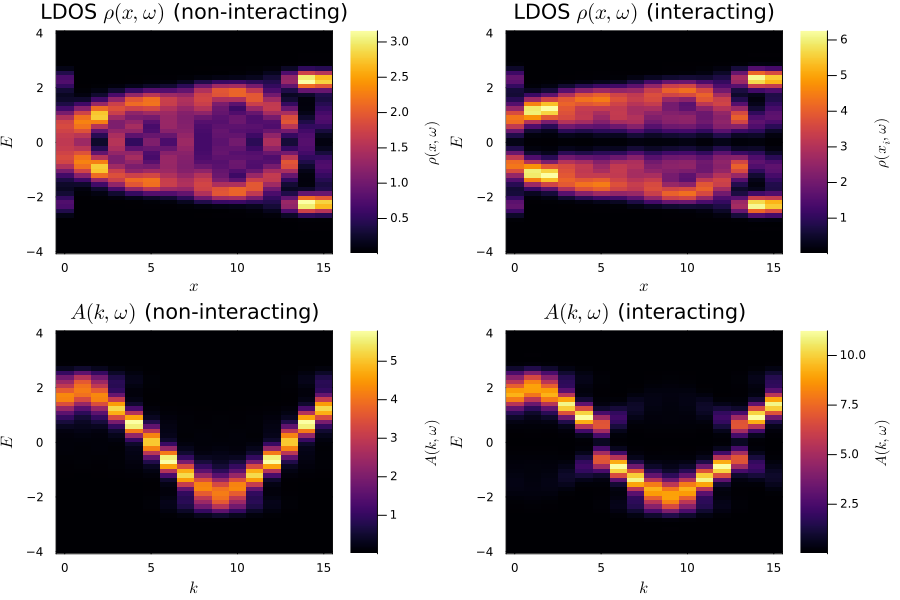

In [10]:
kvals = range(0, N - 1; length=num_k)
xvals = range(0, N - 1; length=num_x)

p1 =
    heatmap(
      xvals, E,           # x and y axes
      ldos_sample_0;        # the i-th LDOS matrix
      xlabel            = L"x",
      ylabel            = L"E",
      title             = "LDOS " * L"\rho(x,\omega)" *  " (non-interacting)",
      title_fontsize    = 12,
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
    #   cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         = L"\rho(x,\omega)" ,
      cbar_titlefontsize = 12
    )

p2 = 
    heatmap(
      xvals, E,           # x and y axes
      ldos_sample;        # the i-th LDOS matrix
      xlabel            = L"x",
      ylabel            = L"E",
      title             = "LDOS " * L"\rho(x,\omega)" *  " (interacting)",
      title_fontsize    = 12,
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
    #   cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         = L"\rho(x_i,\omega)" ,
      cbar_titlefontsize = 12
    )

p3 = heatmap(
      kvals, E,           # x and y axes
      Ak_0;        # 
    #   title             =  titles[i],
      xlabel            = L"k",
      ylabel            = L"E" ,
      title            = L"A(k,\omega)" *  " (non-interacting)",
      title_fontsize   = 12,
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
      # cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         =  L"A(k,\omega)",
      cbar_titlefontsize = 12
    )

p4 = heatmap(
      kvals, E,           # x and y axes
      Ak;        # 
    #   title             =  titles[i],
      xlabel            = L"k",
      ylabel            = L"E" ,
      title            =  L"A(k,\omega)" *  " (interacting)",
      title_fontsize   = 12,
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
      # cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         =  L"A(k,\omega)",
      cbar_titlefontsize = 12
    )

plot(p1, p2, p3, p4, layout = (2, 2), size=(900,600))

## Example 2: Non-interacting 2D Hamiltonian with quasiperiodic potential

### Construction of the 2D Hamiltonian with quasiperiodic super-moiré potential

In [11]:
D = 2 # spatial dimension 
Lx, Ly= 4, 4 # number of pseudospin sites in x and y directions
Nx, Ny = 2^Lx, 2^Ly #number of real sites in x and y directions
L = Lx + Ly # total number of spin sites
N = Nx * Ny #total number of real sites

t = 1 # hopping parameter

#------------------------- Build 2D QC Hamiltonian -------------------------

H0 = Hamiltonians.build_hamiltonian("qc2dsquare", Lx, Ly, mparam_dict=Dict(:t => t));

### Computing the Chebyshev polynomials

In [12]:
ev, Nmu = 20, 50
E = range(-8, 8, ev) #Energy range for the density calculation
# Normalized energy
e  = 0.2                      # small “epsilon” to avoid exactly eigs at ±1
W2 = (maximum(E) - minimum(E)) / 2   # half‐width of the energy range
a  = (maximum(E) + minimum(E)) / 2   # center of the energy range

E_norm = (E .- a) ./ (W2)  # now spectrum in [−1+ erra, 1 - errb]
E_norm = collect(
range(
    minimum(E_norm) + e,
    stop   = maximum(E_norm) - e,
    length = length(E_norm)
)
);

Tn_list0 = QuantumKPM.KPM_Tn(H0, Nmu, E); # Compute the Tn polynomials of the Hamiltonian H without interaction

### Computing the LDOS at E=0

In [13]:
num_x = 16 #number of x values for LDOS sampling

qtt = ldos_qtt_from_Tn(Tn_list0, Nmu, 0.0);
ldos_sample_e0 = reshape(QuantumKPM.get_dens_x_quantics(qtt, num_x, 0, L; D=2), (num_x, num_x));



### Computing the momentum-space spectral function along kx=ky

In [15]:
num_k = 16

Ak0 = []

@showprogress for e in E_norm
    push!(Ak0, QuantumKPM.akdense(Tn_list0, Nmu, e, num_k, D))
end

Ak0=real(reduce(hcat, Ak0)');

Progress: 100%|█████████████████████████████████████████| Time: 0:02:35


### Plotting the results for 2D case

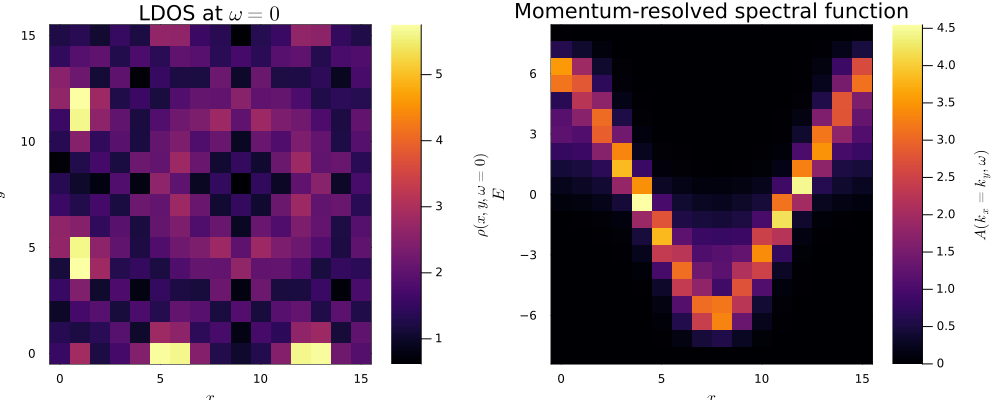

In [16]:
xval = range(0, Nx-1, num_x)
yval = range(0, Ny-1, num_x)

kvals = range(0, Nx-1, num_k)

p1 = heatmap(
      xval, yval,           # x and y axes
      ldos_sample_e0;        # 
    #   title             =  titles[i],
      xlabel            = L"x",
      ylabel            = L"y" ,
      title             = "LDOS at " * L"\omega = 0",
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
      # cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 12,
      cbar_title         =  L"\rho(x,y,\omega = 0)",
      cbar_titlefontsize = 12
    )

p2 = heatmap(
      kvals, E,           # x and y axes
      Ak0;        # 
    #   title             =  titles[i],
      xlabel            = L"x",
      ylabel            = L"E" ,
      title             = "Momentum-resolved spectral function",
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
      # cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 12,
      cbar_title         =  L"A(k_{x}=k_{y},\omega)",
      cbar_titlefontsize = 12
    )

    plot(p1, p2, layout = (1, 2), size=(1000,400))